
Datasets Loaded Successfully!

Missing Values Removed!

========== REGIONAL ANALYSIS ==========

                                                    Stunting  Wasting  \
Region                                                                  
Africa                                                34.684    6.752   
African Region                                        36.328    7.152   
Asia                                                  28.956    9.820   
Australia and New Zealand                              2.880    0.280   
Australia, Europe, New Zealand and Northern Ame...     4.044    1.140   
Caribbean                                             13.192    3.128   
Central America                                       19.608    1.460   
Central Asia                                          15.920    4.020   
Central Asia and Southern Asia                        38.980   14.684   
East Asia and Pacific                                 17.220    4.004   

                         

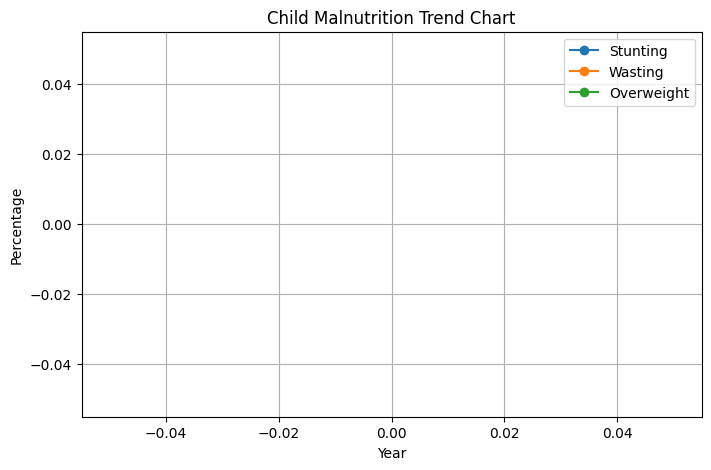

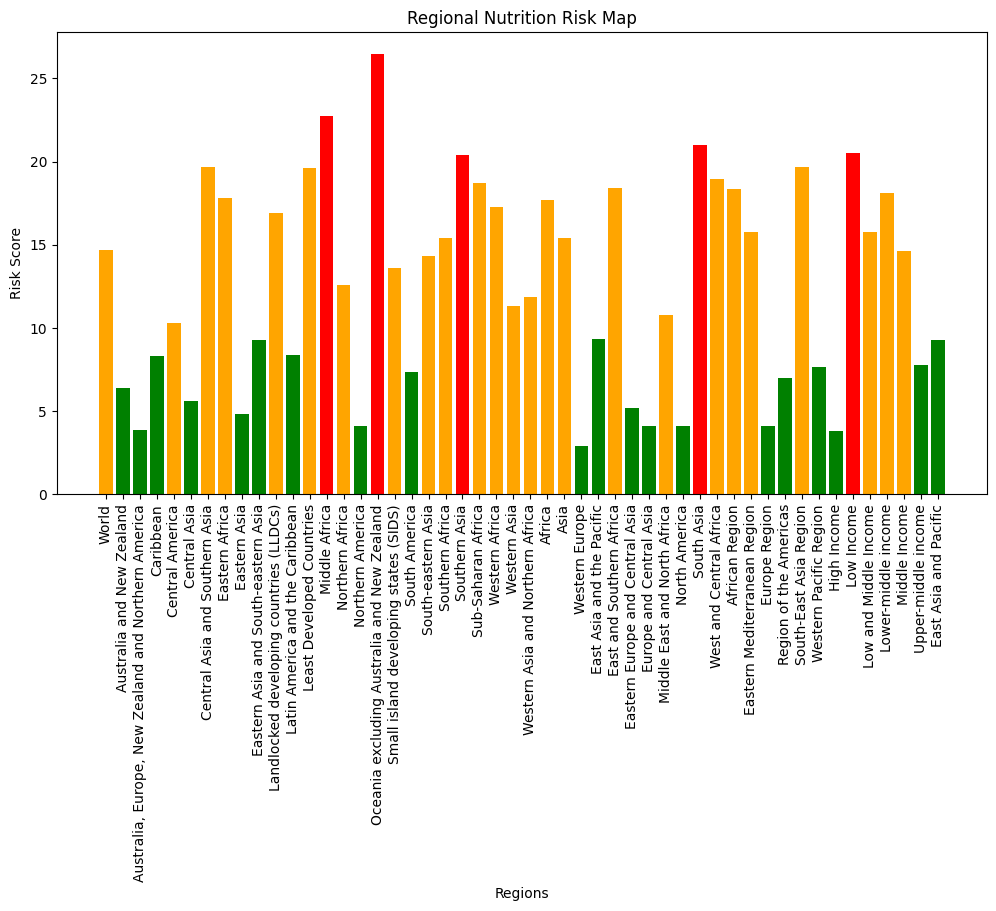


========== NUTRITION INSIGHTS REPORT ==========

Average Stunting : 21.62226989619377
Average Wasting  : 4.586034602076125
Average Overweight : 6.8071003460207615
Average Risk Score : 13.548365397923876

High Risk Regions:

                             Region  Year  Risk Score
0                             World  2000       20.25
1                             World  2001       20.02
450  Central Asia and Southern Asia  2000       29.34
451  Central Asia and Southern Asia  2001       29.09
452  Central Asia and Southern Asia  2002       28.83
453  Central Asia and Southern Asia  2003       28.60
454  Central Asia and Southern Asia  2004       28.32
455  Central Asia and Southern Asia  2005       27.99
456  Central Asia and Southern Asia  2006       27.71
457  Central Asia and Southern Asia  2007       27.30


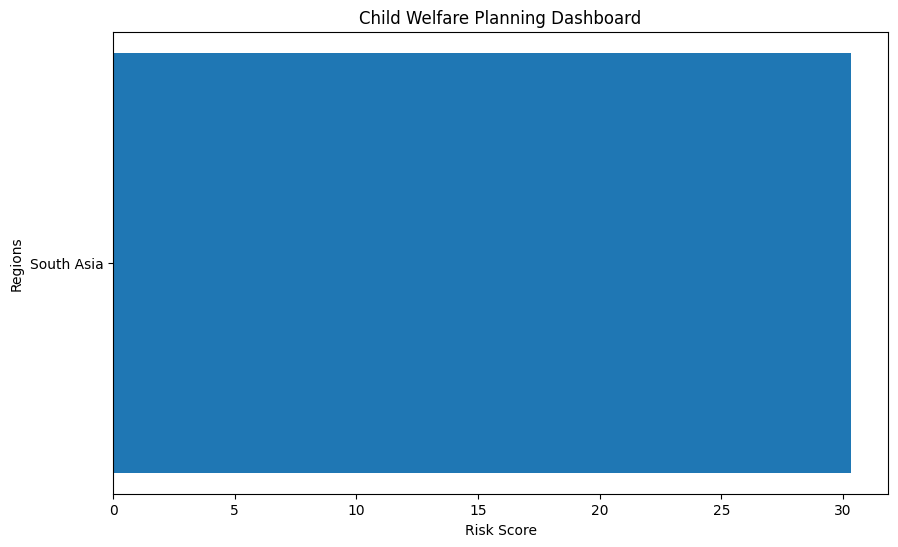


========== SAMPLE TEST INPUT ==========

   Stunting  Wasting  Overweight
0        28       14           6

========== SAMPLE TEST OUTPUT ==========

   Stunting  Wasting  Overweight  Risk Score   Risk Level
0        28       14           6        19.4  Medium Risk

Final Report Saved Successfully!

PROJECT COMPLETED SUCCESSFULLY!


In [1]:
# =========================================================
# CHILD MALNUTRITION ANALYSIS SYSTEM
# ACCORDING TO PROJECT REQUIREMENTS
# =========================================================

# FEATURES:
# 1. Load nutrition indicator datasets
# 2. Analyze malnutrition rates across regions
# 3. Identify correlations between nutrition indicators
# 4. Visualize regional malnutrition patterns
#
# OUTPUTS:
# 1. Child malnutrition trend charts
# 2. Regional nutrition risk maps
# 3. Nutrition indicator insights report
# 4. Child welfare planning dashboard
# =========================================================

# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# LOAD DATASETS
# =========================================================

file_path = "JME_Regional_Global_Estimates_March_2026.xlsx"

stunting_df = pd.read_excel(
    file_path,
    sheet_name="Stunting Prevalence"
)

wasting_df = pd.read_excel(
    file_path,
    sheet_name="Wasting Prevalence"
)

overweight_df = pd.read_excel(
    file_path,
    sheet_name="Overweight Prevalence"
)

print("\nDatasets Loaded Successfully!")

# =========================================================
# SELECT IMPORTANT COLUMNS
# =========================================================

stunting = stunting_df[
    ["Aggregate", "Year", "Both Sexes - Point Estimate"]
].copy()

wasting = wasting_df[
    ["Aggregate", "Year", "Both Sexes - Point Estimate"]
].copy()

overweight = overweight_df[
    ["Aggregate", "Year", "Both Sexes - Point Estimate"]
].copy()

# Rename Columns
stunting.columns = ["Region", "Year", "Stunting"]
wasting.columns = ["Region", "Year", "Wasting"]
overweight.columns = ["Region", "Year", "Overweight"]

# =========================================================
# MERGE DATASETS
# =========================================================

merged_df = pd.merge(
    stunting,
    wasting,
    on=["Region", "Year"]
)

merged_df = pd.merge(
    merged_df,
    overweight,
    on=["Region", "Year"]
)

# =========================================================
# DATA CLEANING
# =========================================================

merged_df["Stunting"] = pd.to_numeric(
    merged_df["Stunting"],
    errors='coerce'
)

merged_df["Wasting"] = pd.to_numeric(
    merged_df["Wasting"],
    errors='coerce'
)

merged_df["Overweight"] = pd.to_numeric(
    merged_df["Overweight"],
    errors='coerce'
)

merged_df.dropna(inplace=True)

print("\nMissing Values Removed!")

# =========================================================
# CREATE RISK SCORE
# =========================================================

merged_df["Risk Score"] = (
    (0.5 * merged_df["Stunting"]) +
    (0.3 * merged_df["Wasting"]) +
    (0.2 * merged_df["Overweight"])
)

# =========================================================
# CLASSIFY RISK LEVELS
# =========================================================

conditions = [
    merged_df["Risk Score"] < 10,

    (merged_df["Risk Score"] >= 10) &
    (merged_df["Risk Score"] < 20),

    merged_df["Risk Score"] >= 20
]

risk_labels = [
    "Low Risk",
    "Medium Risk",
    "High Risk"
]

merged_df["Risk Level"] = np.select(
    conditions,
    risk_labels,
    default="Unknown" # Added default parameter to resolve TypeError
)

# =========================================================
# ANALYZE MALNUTRITION RATES ACROSS REGIONS
# =========================================================

print("\n========== REGIONAL ANALYSIS ==========\n")

regional_analysis = merged_df.groupby("Region")[
    ["Stunting", "Wasting", "Overweight", "Risk Score"]
].mean()

print(regional_analysis.head(10))

# =========================================================
# IDENTIFY CORRELATIONS
# =========================================================

print("\n========== CORRELATION ANALYSIS ==========\n")

correlation = merged_df[
    ["Stunting", "Wasting", "Overweight", "Risk Score"]
].corr()

print(correlation)

# =========================================================
# OUTPUT 1 :
# CHILD MALNUTRITION TREND CHART
# =========================================================

india_data = merged_df[
    merged_df["Region"] == "India"
]

plt.figure(figsize=(8,5))

plt.plot(
    india_data["Year"],
    india_data["Stunting"],
    marker='o',
    label="Stunting"
)

plt.plot(
    india_data["Year"],
    india_data["Wasting"],
    marker='o',
    label="Wasting"
)

plt.plot(
    india_data["Year"],
    india_data["Overweight"],
    marker='o',
    label="Overweight"
)

plt.title("Child Malnutrition Trend Chart")
plt.xlabel("Year")
plt.ylabel("Percentage")

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# OUTPUT 2 :
# REGIONAL NUTRITION RISK MAP
# =========================================================

latest_year = merged_df["Year"].max()

latest_data = merged_df[
    merged_df["Year"] == latest_year
]

plt.figure(figsize=(12,6))

colors = []

for value in latest_data["Risk Score"]:

    if value < 10:
        colors.append("green")

    elif value < 20:
        colors.append("orange")

    else:
        colors.append("red")

plt.bar(
    latest_data["Region"],
    latest_data["Risk Score"],
    color=colors
)

plt.title("Regional Nutrition Risk Map")
plt.xlabel("Regions")
plt.ylabel("Risk Score")

plt.xticks(rotation=90)

plt.show()

# =========================================================
# OUTPUT 3 :
# NUTRITION INDICATOR INSIGHTS REPORT
# =========================================================

print("\n========== NUTRITION INSIGHTS REPORT ==========\n")

print("Average Stunting :", merged_df["Stunting"].mean())
print("Average Wasting  :", merged_df["Wasting"].mean())
print("Average Overweight :", merged_df["Overweight"].mean())
print("Average Risk Score :", merged_df["Risk Score"].mean())

print("\nHigh Risk Regions:\n")

high_risk = merged_df[
    merged_df["Risk Level"] == "High Risk"
]

print(
    high_risk[
        ["Region", "Year", "Risk Score"]
    ].head(10)
)

# =========================================================
# OUTPUT 4 :n
# CHILD WELFARE PLANNING DASHBOARD
# =========================================================

top10 = merged_df.sort_values(
    by="Risk Score",
    ascending=False
).head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["Region"],
    top10["Risk Score"]
)

plt.title("Child Welfare Planning Dashboard")
plt.xlabel("Risk Score")
plt.ylabel("Regions")

plt.show()

# =========================================================
# SAMPLE TEST INPUT
# =========================================================

print("\n========== SAMPLE TEST INPUT ==========\n")

sample_input = pd.DataFrame({
    "Stunting": [28],
    "Wasting": [14],
    "Overweight": [6]
})

print(sample_input)

# =========================================================
# SAMPLE TEST OUTPUT
# =========================================================

sample_input["Risk Score"] = (
    (0.5 * sample_input["Stunting"]) +
    (0.3 * sample_input["Wasting"]) +
    (0.2 * sample_input["Overweight"])
)

if sample_input["Risk Score"][0] < 10:
    level = "Low Risk"

elif sample_input["Risk Score"][0] < 20:
    level = "Medium Risk"

else:
    level = "High Risk"

sample_input["Risk Level"] = level

print("\n========== SAMPLE TEST OUTPUT ==========\n")

print(sample_input)

# =========================================================
# SAVE FINAL OUTPUT
# =========================================================

merged_df.to_csv(
    "child_malnutrition_final_report.csv",
    index=False
)

print("\nFinal Report Saved Successfully!")

# =========================================================
# END OF PROJECT
# =========================================================

print("\nPROJECT COMPLETED SUCCESSFULLY!")